# Transfer Learning and Distillation Experiments

This notebook implements VGG16 feature extraction and knowledge distillation using the tuned baseline architecture as the student.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import sys
import json
import random
import pathlib
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras import layers

from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

KAGGLE_HELPERS_PARENT = "/kaggle/input/datasets/omosaad/helpers"
KAGGLE_HELPERS_DIR = "/kaggle/input/datasets/omosaad/helpers/helpers"




import sys
import importlib

# Point to the folder containing the 'helpers' folder
sys.path.append('/content/drive/MyDrive/Colab Notebooks')

# import the functions from utilities
#from helpers import data_utils, model_utils, training_utils

# Reload the module to reflect changes without restarting the kernel
#importlib.reload(utils)

from helpers import data_utils, model_utils, training_utils

"""
try:
    from helpers import data_utils, model_utils, training_utils
except ModuleNotFoundError:
    for p in [KAGGLE_HELPERS_PARENT, KAGGLE_HELPERS_DIR]:
        if os.path.isdir(p) and p not in sys.path:
            sys.path.append(p)
    from helpers import data_utils, model_utils, training_utils
"""

keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


TensorFlow: 2.19.0
Keras: 3.13.2


In [ ]:
USE_COLAB = True
USE_KAGGLE = False  # Set True when running on Kaggle

In [ ]:
# Configuration
if USE_KAGGLE:
    DATASET_ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/"
    SAVE_DIR = pathlib.Path("/kaggle/working/saved_models")
elif USE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATASET_ROOT = "/content/drive/MyDrive/x-ray-dataset/"
    SAVE_DIR = pathlib.Path("/content/drive/MyDrive/saved_models")
else:
    DATASET_ROOT = "dataset"
    SAVE_DIR = pathlib.Path("saved_models")

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")  # merged into training pool if present
TEST_DIR = os.path.join(DATASET_ROOT, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
VAL_SPLIT = 0.1
AUTOTUNE = tf.data.AUTOTUNE

for split_path in [TRAIN_DIR, TEST_DIR]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Missing directory: {split_path}")

SAVE_DIR.mkdir(parents=True, exist_ok=True)

TEACHER_CHECKPOINT_PATH = SAVE_DIR / "vgg16_frozen_best_checkpoint.keras"
STUDENT_CHECKPOINT_PATH = SAVE_DIR / "baseline_cnn_distilled_best_checkpoint.keras"
STUDENT_BASE_PATH = SAVE_DIR / "baseline_cnn_tuned.keras"

runtime_name = "Kaggle" if USE_KAGGLE else ("Google Colab" if USE_COLAB else "Local")
print(f"Environment: {runtime_name}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Model artifacts will be stored in: {SAVE_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment: Google Colab
Dataset root: /content/drive/MyDrive/x-ray-dataset/
Model artifacts will be stored in: /content/drive/MyDrive/saved_models


In [ ]:
# Bind a notebook-local saver without redefining utility functions here.
save_model_with_meta = training_utils.make_model_saver(SAVE_DIR)


In [ ]:
# Gather train(+optional original val) and test paths/labels
all_train_paths, all_train_labels, test_paths, test_labels = data_utils.gather_split_paths_labels(
    TRAIN_DIR,
    TEST_DIR,
    val_dir=VAL_DIR,
)

if len(np.unique(all_train_labels)) < 2:
    raise ValueError("Both NORMAL and PNEUMONIA classes must exist in the training pool.")

print(f"Training pool size (train + optional original val): {len(all_train_paths)} images")
print(f"  NORMAL={(all_train_labels==0).sum()}, PNEUMONIA={(all_train_labels==1).sum()}")
print(f"Test set size: {len(test_paths)} images")


Training pool size (train + optional original val): 5232 images
  NORMAL=1349, PNEUMONIA=3883
Test set size: 624 images


In [ ]:
data_augmentation = data_utils.build_data_augmentation(
    rotation=30,
    width_shift=0.1,
    height_shift=0.1,
    shear=0.2,
    zoom=0.2,
)

# Build finite datasets; imbalance is handled via class_weight only.
train_ds, val_ds, test_ds, ds_meta = data_utils.build_train_val_test_datasets(
    all_train_paths,
    all_train_labels,
    test_paths,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    seed=42,
    #use_balanced_sampling=False,
    autotune=AUTOTUNE,
)

train_ds_vgg16, val_ds_vgg16, test_ds_vgg16, _ = data_utils.build_train_val_test_datasets(
    all_train_paths,
    all_train_labels,
    test_paths,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    seed=42,
    #use_balanced_sampling=False,
    preprocess_fn=keras.applications.vgg16.preprocess_input,
    autotune=AUTOTUNE,
)

class_weights = data_utils.compute_class_weights(ds_meta["train_labels_raw"], strategy="balanced")
print(f"Train split -> NORMAL={ds_meta['normal_count']}, PNEUMONIA={ds_meta['pneumonia_count']}")
print(f"Validation size: {len(ds_meta['val_labels'])}")
print("Class weights:", class_weights)
print("Datasets are ready.")


Train split -> NORMAL=1214, PNEUMONIA=3494
Validation size: 524
Class weights: {0: 1.9390444810543657, 1: 0.6737263880938752}
Datasets are ready.


## VGG16 Feature Extraction (Frozen Base)


In [ ]:
teacher_model = model_utils.build_vgg16_model(
    img_size=IMG_SIZE,
    augmentation_layer=data_augmentation,
    dense_units=256,
    dense_units_2=128,
    #dense_units_3=64,
    dropout=0.5,
    learning_rate=1e-4,
    freeze_base=True,
    name="vgg16_frozen",
)

teacher_callbacks = training_utils.get_training_callbacks(
    checkpoint_path=TEACHER_CHECKPOINT_PATH,
    patience=5,
    monitor="val_accuracy",
)

teacher_history = teacher_model.fit(
    train_ds_vgg16,
    validation_data=val_ds_vgg16,
    epochs=30,
    callbacks=teacher_callbacks,
    class_weight=class_weights,
    verbose=1,
)
print(f"Best teacher checkpoint saved to: {TEACHER_CHECKPOINT_PATH}")


Epoch 1/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6518 - auc: 0.6275 - loss: 0.9226 - precision: 0.8152 - recall: 0.6968
Epoch 1: val_accuracy improved from None to 0.75573, saving model to /content/drive/MyDrive/saved_models/vgg16_frozen_best_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/vgg16_frozen_best_checkpoint.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.7011 - auc: 0.7455 - loss: 0.6800 - precision: 0.8577 - recall: 0.7161 - val_accuracy: 0.7557 - val_auc: 0.9299 - val_loss: 0.6272 - val_precision: 0.9677 - val_recall: 0.6941 - learning_rate: 1.0000e-04
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8225 - auc: 0.8860 - loss: 0.4291 - precision: 0.9176 - recall: 0.8389
Epoch 2: val_accuracy improved from 0.75573 to 0.84924, saving model to /content/drive/MyDrive/saved_models/vgg16_frozen_best_checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/saved_models/vgg

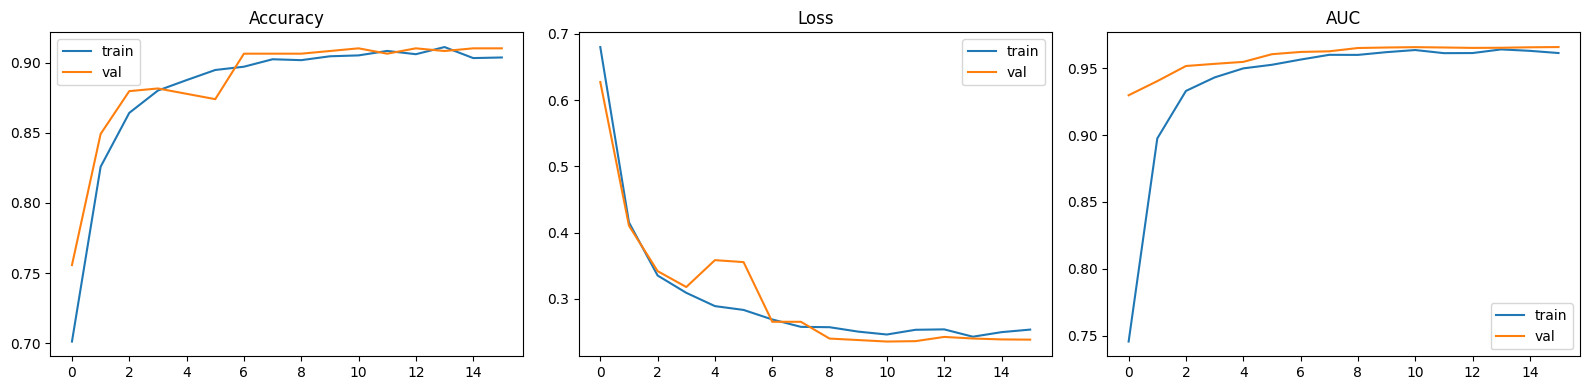

Best threshold (val PNEUMONIA F1=0.953): 0.30

Test metrics: {'accuracy': 0.7660256410256411, 'auc': 0.8896559281174665, 'precision': 0.7373540856031129, 'recall': 0.9717948717948718, 'f1': 0.838495575221239}

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.90      0.42      0.58       234
   PNEUMONIA       0.74      0.97      0.84       390

    accuracy                           0.77       624
   macro avg       0.82      0.70      0.71       624
weighted avg       0.80      0.77      0.74       624



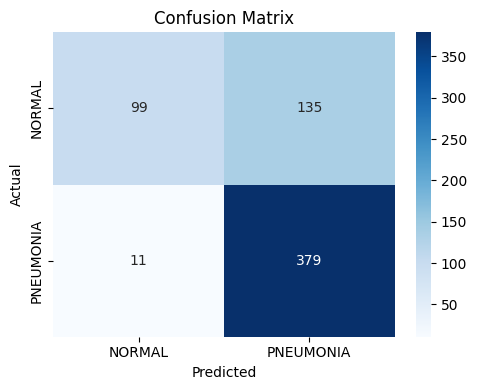

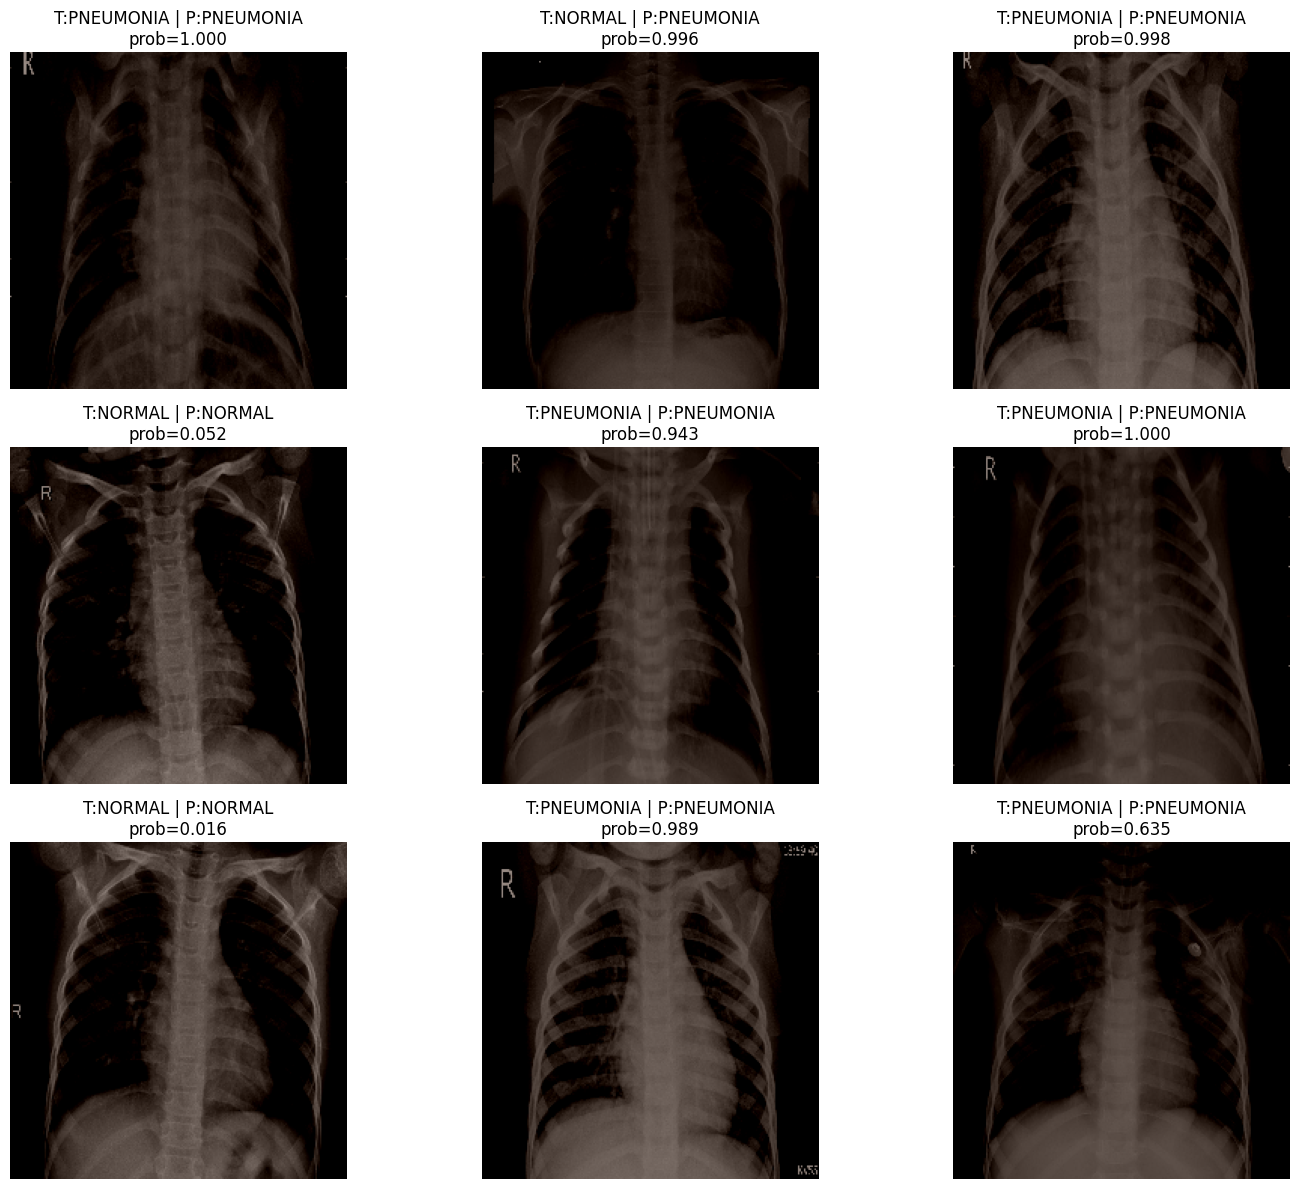

Saved model to: /content/drive/MyDrive/saved_models/vgg16_frozen.keras
Saved metadata to: /content/drive/MyDrive/saved_models/vgg16_frozen_meta.json


In [ ]:
from helpers import visualization

# Training curves
visualization.plot_training_curves(teacher_history)

# Threshold tuning on validation set
teacher_threshold, best_f1, _, _ = training_utils.tune_threshold(teacher_model, val_ds_vgg16)
print(f"Best threshold (val PNEUMONIA F1={best_f1:.3f}): {teacher_threshold:.2f}")

# Test evaluation
teacher_metrics, teacher_report, y_true, y_prob, y_pred = training_utils.evaluate_model(
    teacher_model,
    test_ds_vgg16,
    teacher_threshold,
)
print(f"\nTest metrics: {teacher_metrics}")
print(f"\nClassification Report:\n{classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA'])}")

# Confusion matrix and qualitative predictions
visualization.plot_confusion_matrix(y_true, y_pred)
visualization.plot_sample_predictions(teacher_model, test_ds_vgg16, teacher_threshold, n=9)

# Save model + metadata
save_model_with_meta(
    teacher_model,
    "vgg16_frozen",
    teacher_metrics,
    teacher_history,
    {"learning_rate": 1e-4, "frozen_base": True},
    teacher_threshold,
)

## Comparison Across All 3 Models


                     Model  Test Acc  Test AUC  Precision    Recall        F1  \
0             Baseline CNN  0.806090  0.892445   0.767396  0.989744  0.864502   
1  Baseline CNN (tuned HP)  0.830128  0.927723   0.787449  0.997436  0.880090   
2      VGG16 (frozen base)  0.766026  0.889656   0.737354  0.971795  0.838496   

   Best Threshold  Trainable Params  
0             0.8           1207201  
1             0.4           4820801  
2             0.3            164353  


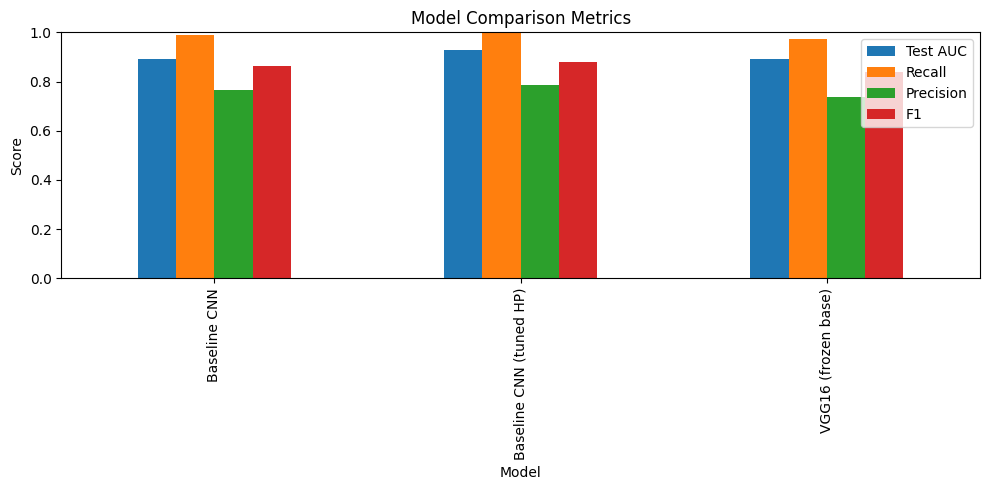

In [ ]:
records = []
for model_name, label in [
    ("baseline_cnn", "Baseline CNN"),
    ("baseline_cnn_tuned", "Baseline CNN (tuned HP)"),
    ("vgg16_frozen", "VGG16 (frozen base)")
]:
    meta = training_utils.load_model_meta(SAVE_DIR, model_name)
    if meta is None:
        continue
    m = meta["metrics"]
    records.append({
        "Model": label,
        "Test Acc": m.get("accuracy"),
        "Test AUC": m.get("auc"),
        "Precision": m.get("precision"),
        "Recall": m.get("recall"),
        "F1": m.get("f1"),
        "Best Threshold": meta.get("threshold"),
        "Trainable Params": meta.get("model_params", {}).get("trainable"),
    })

comparison_df = pd.DataFrame(records)
print(comparison_df)

# Bar chart for AUC / recall / precision / F1
if not comparison_df.empty:
    metric_cols = ["Test AUC", "Recall", "Precision", "F1"]
    ax = comparison_df.set_index("Model")[metric_cols].plot(kind="bar", figsize=(10, 5))
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title("Model Comparison Metrics")
    plt.tight_layout()
    plt.show()
